In [3]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:
df=pd.read_csv(r"C:\Users\hp\Downloads\archive (3)\Churn_Modelling.csv")


In [6]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Text(0, 0.5, 'EstimatedSalary')

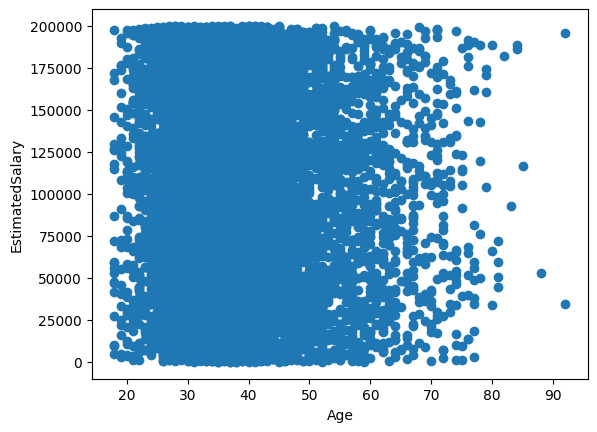

In [33]:
plt.scatter(df['Age'],df['EstimatedSalary'])
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')

In [34]:
X=df.iloc[:,6:7]
y=df.iloc[:,-1]

In [35]:
X

,Age
0,42
1,41
2,42
3,39
4,43
...,...
9995,39
9996,35
9997,36
9998,42


In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=2)

In [37]:
X_test

,Age
7878,38
3224,41
1919,56
4432,33
4835,34
...,...
9073,60
8584,19
5390,38
5092,39


In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
lr= LinearRegression()

In [40]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
X_test

,Age
7878,38
3224,41
1919,56
4432,33
4835,34
...,...
9073,60
8584,19
5390,38
5092,39


In [42]:
y_test


7878    1
3224    1
1919    1
4432    0
4835    0
       ..
9073    1
8584    0
5390    1
5092    1
2964    0
Name: Exited, Length: 2000, dtype: int64

In [43]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([0.19550687])

Text(0, 0.5, 'EstimatedSalary')

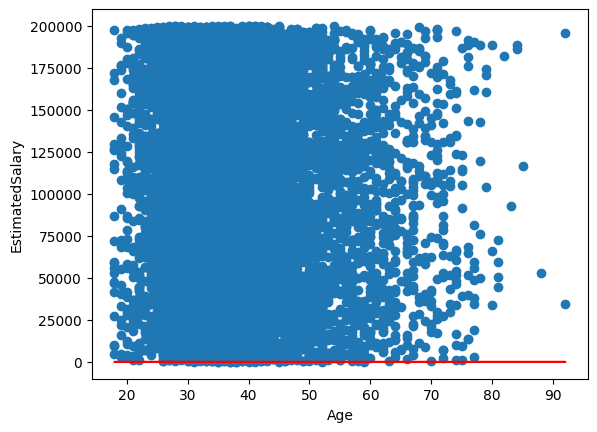

In [46]:
plt.scatter(df['Age'],df['EstimatedSalary'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
            

In [48]:
m= lr.coef_
m

array([0.01120951])

In [50]:
b=lr.intercept_
b

np.float64(-0.23045437481630088)

In [51]:
m*8.58+b

array([-0.13427681])

In [52]:
m*100+b

array([0.89049626])